# Respuesta a una pregunta de negocio de las partes interesadas

En este notebook se analiza la siguiente pregunta de negocio:

¿Qué grupo de edad tiene el mayor balance anual promedio y menor proporción de préstamos hipotecarios y personales, para identificar clientes con capacidad potencial para nuevos productos de inversión o ahorro?

El análisis se realiza a partir de `dataset.csv`. El notebook normaliza los encabezados y conserva las variables necesarias para el análisis.

La exploración compara el balance anual promedio y la distribución de préstamos hipotecarios y personales entre grupos de edad.

## Carga y preparación de la información

Se carga `dataset.csv` mediante las utilidades del proyecto y se normalizan sus encabezados con `clean_heads`. Después, se seleccionan las cuatro columnas que se utilizarán en el análisis: edad, balance anual promedio, préstamo hipotecario y préstamo personal. Finalmente, se muestran las primeras filas del DataFrame resultante.

In [11]:
from bank_customer.utils.paths import get_path_raw
from bank_customer.extract.extract import extract
from bank_customer.transform.clean_df import clean_heads, keep_columns
from bank_customer.transform.transform import get_keep_columns

KEEP_COLUMNS = [
    'age',
    'average_yearly_balance',
    'housing_loan',
    'personal_loan'
]

df = clean_heads(extract(get_path_raw('dataset.csv')))
df = df[KEEP_COLUMNS]

df.head()

,age,average_yearly_balance,housing_loan,personal_loan
0,58,2143,yes,no
1,44,29,yes,no
2,33,2,yes,yes
3,47,1506,yes,no
4,33,1,no,no


## Generación de grupos a partir de rangos de edad

Se clasifica a cada cliente en uno de cuatro rangos de edad: 20-30, 30-40, 40-50 y 50-60 años. A continuación, se calcula para cada rango el balance anual promedio, mínimo y máximo, y se muestra la cantidad de clientes por grupo. El DataFrame `stats_df` conserva estas estadísticas para la visualización posterior.

In [12]:
import pandas as pd
bins = [20,30,40,50,60]
labels = ['20-30','30-40','40-50','50-60']

df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)



stats_df = (df.groupby('age_group')['average_yearly_balance']
            .agg(['mean', 'min', 'max'])
            .reset_index()
)

df['age_group'].value_counts().sort_index()

age_group
20-30     6983
30-40    17687
40-50    11239
50-60     8067
Name: count, dtype: int64

## Análisis por rango de edad

Las siguientes visualizaciones comparan el balance anual promedio y los préstamos de los clientes en cada rango de edad.

### Balance anual promedio por rango de edad

Se genera un gráfico de barras con el balance anual promedio de cada grupo de edad, utilizando la columna `mean` de `stats_df`. Esto permite identificar visualmente el rango con el mayor balance promedio.

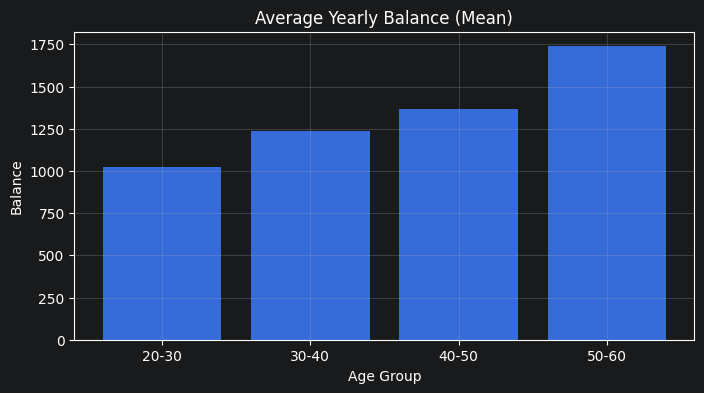

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(stats_df['age_group'],stats_df['mean'])
plt.title('Average Yearly Balance (Mean)')
plt.xlabel('Age Group')
plt.ylabel('Balance')
plt.grid(alpha=0.35)
plt.show()


## Préstamos personales por rango de edad

Se repite el conteo para la columna `personal_loan`. La tabla resultante y el gráfico de barras muestran la cantidad de clientes con y sin préstamo personal en cada grupo de edad.

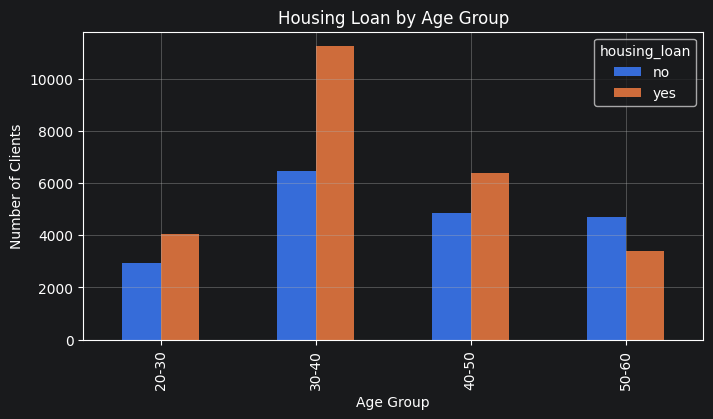

In [14]:
df.groupby('age_group')['housing_loan'].value_counts()

housing_stats = (
    df.groupby('age_group')['housing_loan']
    .value_counts()
    .unstack(fill_value=0)
)

housing_stats.plot(
    kind='bar',
    figsize=(8,4),
)

plt.title('Housing Loan by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Clients')
plt.grid(0.35)
plt.show()

### Préstamos personales por rango de edad

Se repite el conteo para la columna `personal_loan`. La tabla resultante y el gráfico de barras muestran la cantidad de clientes con y sin préstamo personal en cada grupo de edad.

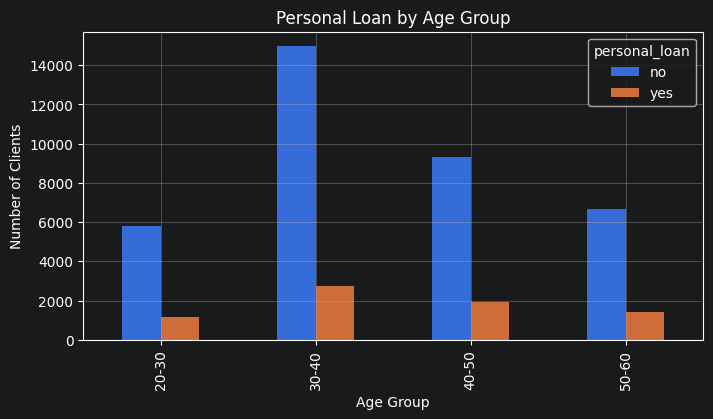

In [15]:
df.groupby('age_group')['personal_loan'].value_counts()

personal_stats = (
    df.groupby('age_group')['personal_loan']
    .value_counts()
    .unstack(fill_value=0)
)

personal_stats.plot(
    kind='bar',
    figsize=(8,4),
)

plt.title('Personal Loan by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Clients')
plt.grid(0.35)
plt.show()